<a href="https://colab.research.google.com/github/CatCan55/Non-Boolean-Quantum-Amplitude-Amplification/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
%pip install qiskit # needed in colab
%pip install pylatexenc
import pylatexenc

from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit import barrier
from qiskit.circuit.library import UnitaryGate


import numpy as np
import sympy as sp

Non-boolean amplitude amplification algorithm

1. initialize
2. for k:= 1 to K do
3. if k is odd then
4. update with U_phi
5. else
6. update with U_phi^adj
7. end if
8. end for
9. Measure the ancilla in the 0/1 basis.


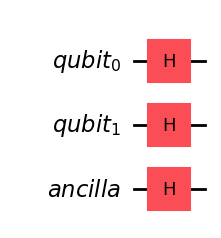

In [8]:
num_qubits = 2
qubit = QuantumRegister(num_qubits, 'qubit')
ancilla = AncillaRegister(1, 'ancilla')

circuit_1 = QuantumCircuit(qubit, ancilla)

# first we initialize, taking A_0 = H here
circuit_1.h(qubit)
circuit_1.h(ancilla)

display(circuit_1.draw('mpl'))

Prep = circuit_1.to_gate()

Apply U_phi when k is odd. Apply U_phi_adj when k is even.

In [9]:
N = 2 ** num_qubits
# Define a function of range [0,1]
def g(x):
    return x/(N-1)

# Compute the diagonal entries of the phase oracle matrix.
# These will amplify states, prioritizing when g(x) is closer to 1.
# The possible states for x are 0, 1, ..., N-1.
diagonal_entries = [np.exp(1j * np.pi * g(x)) for x in range(N)]

# Create the diagonal matrix for the phase oracle
diagonal_matrix = np.diag(diagonal_entries)

# Create the phase oracle operator
phase_oracle = Operator(diagonal_matrix)
phase_oracle_adj = phase_oracle.adjoint()

# Creat the gates
phase_oracle_gate = UnitaryGate(phase_oracle.data, label='U_phi')
phase_oracle_adj_gate = UnitaryGate(phase_oracle_adj.data, label='U_phi_adj')

In [ ]:
# Marker oracle: we alternate applying U_phi and U_phi_adj, to remain within the
# span of the correct basis vectors, for the algorithm to work.
# In other words, for odd iterations we apply U_phi
# For even iterations we apply U_phi_adj
# We set up these two gates, calling them odd_gate and even_gate.

def apply_U_Phi(circuit):
  qubit_list = [ancilla[0]] + list(qubit)   # control first, then all target qubits

  # ancilla = 0 -> apply phase_oracle
  circuit.x(ancilla[0])
  circuit.append(controlled_phase_oracle, qubit_list)
  circuit.x(ancilla[0])

  # ancilla = 1 -> apply phase_oracle_adj
  circuit.append(controlled_phase_oracle_adj, qubit_list)

  odd_marker_circuit = QuantumCircuit(qubit,ancilla)

  odd_gate = U_phi_circuit.to_gate(label='U_phi')

In [ ]:
# Circuit for the adjoint of U_phi

U_phi_adjoint_circuit = U_phi_circuit.inverse()

In [ ]:
even_gate = U_phi_adjoint_circuit.to_gate(label='U_phi^+')

In [ ]:
q1 = QuantumRegister(num_qubits, 'q1')
a1 = AncillaRegister(1, 'a1')
odd_iteration_circuit = QuantumCircuit(q1, a1)
# odd_iteration_circuit.append(odd_gate, [q1[0], a1[0]])
# odd_iteration_circuit.append(diffuser_gate, [q1[0], a1[0]])

# display(odd_iteration_circuit.draw('mpl'))

In [ ]:
q2 = QuantumRegister(num_qubits, 'q2')
a2 = AncillaRegister(1, 'a2')
even_iteration_circuit = QuantumCircuit(q2, a2)
# even_iteration_circuit.append(even_gate, [q1[0], a1[0]])
# even_iteration_circuit.append(diffuser_gate, [q1[0], a1[0]])

In [ ]:
# When A_0 = H, diffuser is the same as in Grover's algorithm
qubit = QuantumRegister(num_qubits, 'qubit')
ancilla = AncillaRegister(1, 'ancilla')

quantum_register = list(qubit) + list(ancilla)

diffuser_circuit = QuantumCircuit(qubit, ancilla, name="diffuser")

diffuser_circuit.compose(Prep, inplace=True)
diffuser_circuit.x(quantum_register)
diffuser_circuit.mcz(quantum_register[:-1], quantum_register[-1])
diffuser_circuit.x(quantum_register)
diffuser_circuit.compose(Prep.inverse(), inplace=True)

###

diffuser_circuit.draw(output="mpl")
D = diffuser_circuit.to_gate()

This is where we run the iterations on the circuit

In [ ]:
final_circuit = QuantumCircuit(quantum_register, name="NBQAA circuit")

final_circuit.compose(Prep, qubits=quantum_register[:], inplace=True)



# when j=0 we are on iteration 1 which is odd, so check parity of j+1 instead
for j in range(K):
  if (j+1) % 2 == 0:
    final_circuit.barrier()
    final_circuit.compose(Ueven, inplace=True)
    final_circuit.barrier()
    final_circuit.compose(D, qubits=quantum_register[:], inplace=True)
  else:
    final_circuit.barrier()
    final_circuit.compose(Uodd, inplace=True)
    final_circuit.barrier()
    final_circuit.compose(D, qubits=quantum_register[:], inplace=True)

final_circuit.draw(output="mpl")